# Flood index complement

Here i'm just doing the same as in flood_index.ipynb, but for the two states that have no subdistricts: construct the threshold but use district level data instead of subdistrict.

In [4]:
import numpy as np
import pandas
import pandas as pd
import glob
from lmoments3 import distr
from pandas import read_csv
import lmoments3.distr as distr

In [5]:
def load_year(filepath):
    df = pd.read_csv(filepath, low_memory=False)  # or read_parquet, read_feather, etc.

    # Metadata columns to keep
    meta_cols = ['OBJECTID_1', 'REMARKS', 'STATE_LGD', 'STATE_UT', 'DIST_LGD', 'system:index',
                 'Shape_Area',	'Shape_Leng',	'.geo', 'DISTRICT', 'OBJECTID']

    # Date columns are everything else
    date_cols = [c for c in df.columns if c not in meta_cols]

    # Melt to long format: one row per subdistrict-day
    df_long = df.melt(
        id_vars=meta_cols,
        value_vars=date_cols,
        var_name='col_name',
        value_name='precip_max'
    )

    # Parse date from column name (format: YYYYMMDD_YYYY_MM_DD)
    df_long['date'] = pd.to_datetime(df_long['col_name'].str[:8], format='%Y%m%d')
    df_long['month'] = df_long['date'].dt.month
    df_long['year'] = df_long['date'].dt.year

    return df_long.drop(columns='col_name')

In [6]:
filepath = '/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/daily max pr era5 missing states/MAX_Precip_Districts_1995.csv'
pr_1995 = load_year(filepath)
pr_1995.columns

Index(['OBJECTID_1', 'REMARKS', 'STATE_LGD', 'STATE_UT', 'DIST_LGD',
       'system:index', 'Shape_Area', 'Shape_Leng', '.geo', 'DISTRICT',
       'OBJECTID', 'precip_max', 'date', 'month', 'year'],
      dtype='str')

In [7]:
import glob
import pandas as pd
import lmoments3.distr as distr # Assuming this is your GEV library based on the code

files = sorted(glob.glob('/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/daily max pr era5 missing states/*.csv'))

# Load and concatenate the data
df = pd.concat([load_year(f) for f in files], ignore_index=True)

# -------------------------------------------------------------------
# NEW STEP: Define the custom year (July 1st to June 30th)
# Assumption: You have a column named 'date' that contains the date string.
# If your column has a different name, replace 'date' below.
# -------------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# Assign custom year: If month is Jan-Jun (< 7), subtract 1 from the year.
# This groups Jul 1, 2023 to Jun 30, 2024 under custom_year '2023'.
df['custom_year'] = df['date'].dt.year - (df['date'].dt.month < 7).astype(int)

# (Alternative: If you don't have a 'date' column but have 'year' and 'month' columns as integers):
# df['custom_year'] = df['year'] - (df['month'] < 7).astype(int)
# -------------------------------------------------------------------

print(df.shape)
print(df.head())

# Group by the NEW custom_year instead of the standard year
annual_max_df = df.groupby(['STATE_UT', 'DISTRICT', 'custom_year']).agg(
    annual_max=('precip_max', 'max')
).reset_index()

results = []
# Filter on custom_year instead of year
for (state, district), group in annual_max_df[annual_max_df['custom_year'] <= 2025].groupby(['STATE_UT', 'DISTRICT']):
    vals = group['annual_max'].dropna().values

    if len(vals) < 10:   # optional: avoid unstable fits
        continue

    params = distr.gev.lmom_fit(vals)
    tau = distr.gev.ppf(0.90, **params)

    results.append({
        'STATE': state,
        'DISTRICT': district,
        'THRESHOLD_10YR': tau
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)
threshold_df.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year_2states.csv", index=False)
threshold_df.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year_2states.xlsx", index=False)



(441597, 16)
   OBJECTID_1  REMARKS  STATE_LGD           STATE_UT  DIST_LGD  \
0         375      NaN         12  ARUNACHAL PRADESH       260   
1         376      NaN         12  ARUNACHAL PRADESH       253   
2         377      NaN         12  ARUNACHAL PRADESH       257   
3         378      NaN         12  ARUNACHAL PRADESH       247   
4         379      NaN         12  ARUNACHAL PRADESH       251   

           system:index    Shape_Area     Shape_Leng  \
0  00000000000000000176  5.816784e+09  398742.120013   
1  00000000000000000177  4.920704e+09  596057.004213   
2  00000000000000000178  9.284090e+09  595333.071309   
3  00000000000000000179  3.474706e+09  385206.663491   
4  0000000000000000017a  1.619900e+09  214218.234419   

                                                .geo       DISTRICT  OBJECTID  \
0  {"type":"GeometryCollection","geometries":[{"t...          >NJ>W       375   
1  {"type":"Polygon","coordinates":[[[95.61262487...      CH>NGL>NG       376   
2  {"type"

### Compare the threshold to the actual values

This is the same as in the lood_index.ipynb file but without 'SUB_DIST'.

In [8]:
# for each district count the number of exceedance per custom year
# 1. Merge the thresholds back into the main daily dataframe
exceedance_df = df.merge(
    threshold_df,
    left_on=['STATE_UT', 'DISTRICT'],
    right_on=['STATE', 'DISTRICT'],
    how='inner'
)

# 2. Identify where daily precipitation exceeds the 10-year threshold
exceedance_df['is_exceedance'] = exceedance_df['precip_max'] > exceedance_df['THRESHOLD_10YR']

In [9]:
exceedance_df = exceedance_df.sort_values(by=['STATE_UT', 'DISTRICT', 'date'])
exceedance_df['prev_is_exceedance'] = (
    exceedance_df.groupby(['STATE_UT', 'DISTRICT'])['is_exceedance']
    .shift(1)
    .fillna(False)
)

# A new event starts for a sub-district if it exceeds today but didn't yesterday
exceedance_df['is_new_event_sub'] = exceedance_df['is_exceedance'] & ~exceedance_df['prev_is_exceedance']

# 3. Aggregate to District-Day level
# Rule: If ANY sub-district starts an event, the district gets 1 event start for that day.
# Rule: If ANY sub-district exceeds the threshold, the district gets 1 exceedance day.
district_daily = exceedance_df.groupby(['STATE_UT', 'DISTRICT', 'custom_year', 'date']).agg(
    district_event_start=('is_new_event_sub', 'any'),
    district_exceeded=('is_exceedance', 'any')
).reset_index()

# 4. Final Aggregation to Custom Year
# We sum the daily booleans (True=1, False=0)
exceedance_counts = district_daily.groupby(['STATE_UT', 'DISTRICT', 'custom_year']).agg(
    event_count=('district_event_start', 'sum'),
    exceedance_days_total=('district_exceeded', 'sum')
).reset_index()

In [16]:
# check the difference in names for districts between exceedance_counts and pop and fix exceedance_counts to match
pop_df = read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/district_population.csv")
print(exceedance_counts['DISTRICT'].unique())
print(pop_df['DISTRICT'].unique())

<StringArray>
[                   '>NJ>W',                   'BICHOM',
                'CH>NGL>NG',            'DIB>NG VALLEY',
              'EAST KAMENG',               'EAST SIANG',
                    'KAMLE',              'KEYI PANYOR',
                'KRA DAADI',             'KURUNG KUMEY',
                'LEPA RADA',                    'LOHIT',
                 'LONGDING',      'LOWER DIB>NG VALLEY',
              'LOWER SIANG',          'LOWER SUBANSIRI',
                   'NAMSAI',            'PAKKE KESSANG',
                'PAPUMPARE',                 'SHI YOMI',
                    'SIANG',                   'TAWANG',
                    'TIR>P',              'UPPER SIANG',
          'UPPER SUBANSIRI',              'WEST KAMENG',
               'WEST SIANG',          'EAST G>RO HILLS',
       'EAST JAINTIA HILLS',         'EAST KH>SI HILLS',
 'EASTERN WEST KHASI HILLS',         'NORTH G>RO HILLS',
                  'RI-BHOI',         'SOUTH G>RO HILLS',
    'SOUTH WEST G

In [23]:
# Fix the garbled '>' characters in exceedance_counts
replacements = {
    '>NJ>W': 'ANJAW',
    'CH>NGL>NG': 'CHANGLANG',
    'DIB>NG VALLEY': 'DIBANG VALLEY',
    'LOWER DIB>NG VALLEY': 'LOWER DIBANG VALLEY',
    'TIR>P': 'TIRAP',
    'EAST G>RO HILLS': 'EAST GARO HILLS',
    'NORTH G>RO HILLS': 'NORTH GARO HILLS',
    'SOUTH G>RO HILLS': 'SOUTH GARO HILLS',
    'WEST G>RO HILLS': 'WEST GARO HILLS',
    'SOUTH WEST G>RO HILLS': 'SOUTH WEST GARO HILLS',
    'EAST KH>SI HILLS': 'EAST KHASI HILLS',
    'WEST KH>SI HILLS': 'WEST KHASI HILLS',  # if present
    'SOUTH WEST KH>SI HILLS': 'SOUTH WEST KHASI HILLS',
}

exceedance_counts['DISTRICT'] = exceedance_counts['DISTRICT'].replace(replacements)
pop_df['DISTRICT'] = pop_df['DISTRICT'].replace(replacements)


# Normalize casing to match pop_df (title case) — or uppercase both
exceedance_counts['DISTRICT'] = exceedance_counts['DISTRICT'].str.title()
pop_df['DISTRICT'] = pop_df['DISTRICT'].str.upper().str.strip()
exceedance_counts['DISTRICT'] = exceedance_counts['DISTRICT'].str.upper().str.strip()

# Check what's still unmatched after fixes
unmatched = set(exceedance_counts['DISTRICT']) - set(pop_df['DISTRICT'])
print("Still unmatched:", unmatched)

Still unmatched: set()


In [24]:
exceedance_counts.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events_2states.xlsx", index=False)
exceedance_counts.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events_2states.csv", index=False)

### Plotting

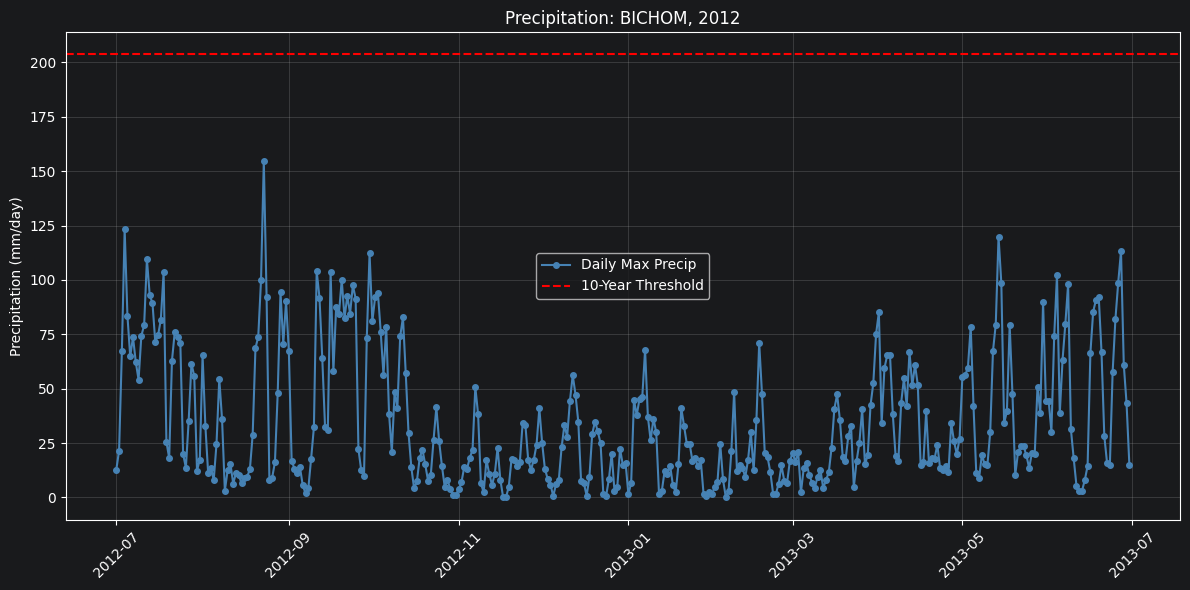

In [14]:
def plot_district_precipitation(df, threshold_df, target_district, target_custom_year,
                               start_date=None, end_date=None):
    # 1. Filter for district and custom year
    district_data = df[
        (df['DISTRICT'] == target_district) &
        (df['custom_year'] == target_custom_year)
    ].sort_values('date')

    if district_data.empty:
        print("No data found.")
        return

    # 2. ZOOM LOGIC: Filter by specific date range if provided
    if start_date and end_date:
        district_data = district_data[
            (district_data['date'] >= start_date) &
            (district_data['date'] <= end_date)
        ]

    # 3. Get Threshold
    threshold = threshold_df[threshold_df['DISTRICT'] == target_district]['THRESHOLD_10YR'].item()

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(district_data['date'], district_data['precip_max'],
             label='Daily Max Precip', color='steelblue', marker='o', markersize=4)

    plt.axhline(y=threshold, color='red', linestyle='--', label='10-Year Threshold')

    # Highlight exceedances within this zoom window
    exceedances = district_data[district_data['precip_max'] > threshold]
    plt.scatter(exceedances['date'], exceedances['precip_max'], color='red', zorder=5)

    plt.title(
    f"Precipitation: {target_district}, {target_custom_year}" if start_date is None
    else f"Zoomed View: {target_district} ({start_date} to {end_date})")
    plt.ylabel("Precipitation (mm/day)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
plot_district_precipitation(
    df,
    threshold_df,
    target_district="BICHOM",
    target_custom_year=2012,
)

### Fix the names